In [189]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



In [190]:
# Load dataset
digits = load_digits()

In [191]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

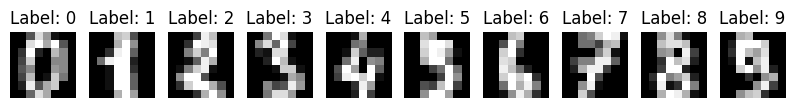

In [192]:
fig, axes = plt.subplots(1, 10, figsize=(10, 3))
for i in range(10):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Label: {digits.target[i]}")
    axes[i].axis('off')

plt.show()

In [193]:
print(digits.data.shape)


(1797, 64)


In [194]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [195]:
digits.target[0]

0

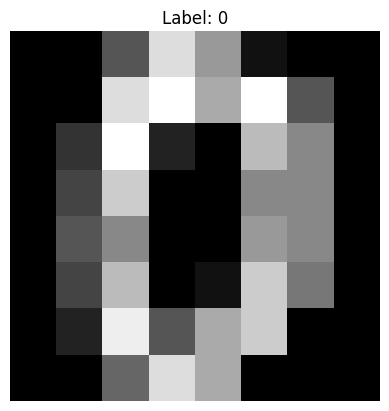

In [196]:
index = 0

# Get the 8x8 image by reshaping the 64 features
image = digits.data[index].reshape(8, 8)

# Display the image
plt.imshow(image, cmap='gray')
plt.title(f'Label: {digits.target[index]}')
plt.axis('off')
plt.show()

In [197]:
# pca = PCA(n_components=0.7)
# pca.fit(digits.data)

# print(f"Number of components to retain 70% variance: {pca.n_components_}")


In [198]:
# reduced_data = pca.transform(digits.data)


In [199]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [200]:
digits = load_digits()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(digits.data)


In [201]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))


Explained variance ratio: [0.14890594 0.13618771]
Total variance captured: 0.28509364823697975


In [202]:
X=digits.data

In [203]:
y=digits.target

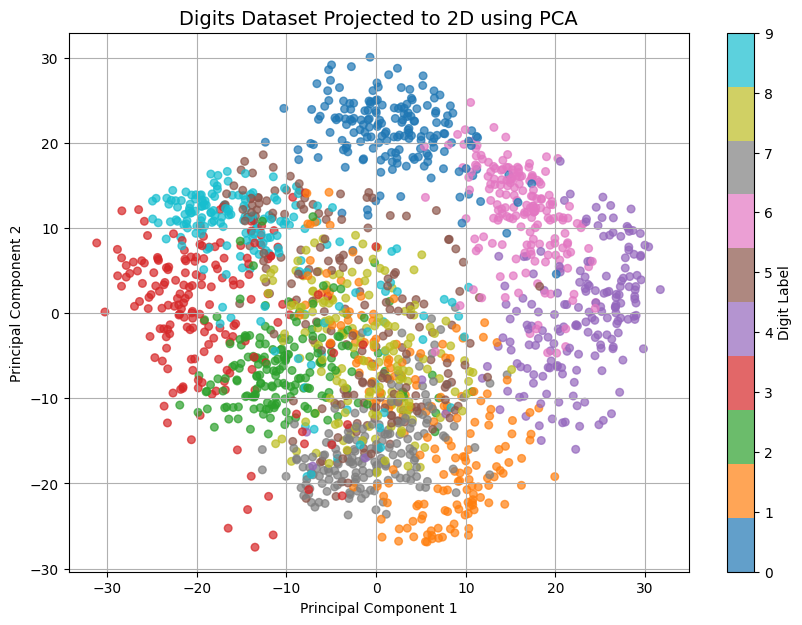

In [204]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=30, alpha=0.7)

plt.title("Digits Dataset Projected to 2D using PCA", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Digit Label")
plt.grid(True)
plt.show()

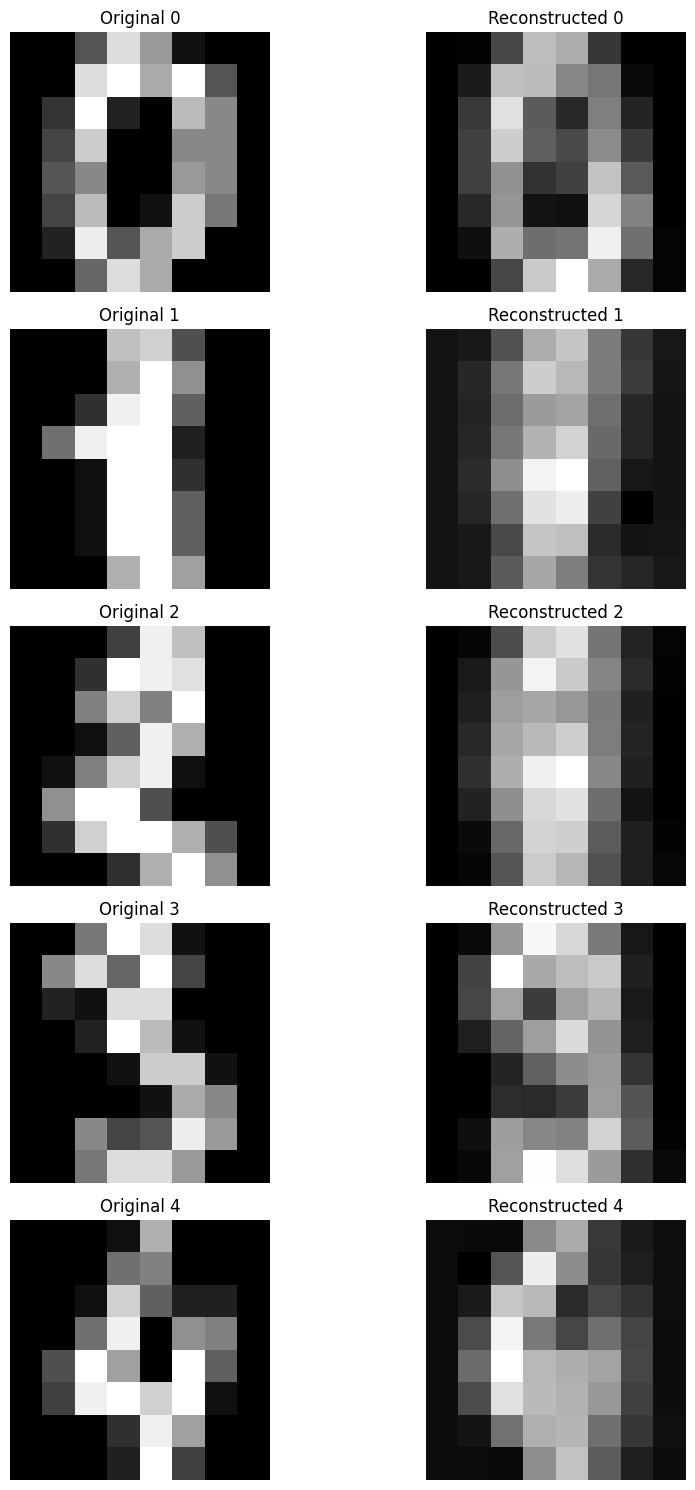

In [205]:
X_reconstructed = pca.inverse_transform(X_pca)

fig, axes = plt.subplots(5, 2, figsize=(10, 15))

for i in range(5):
    axes[i, 0].imshow(X[i].reshape(8, 8), cmap='gray')
    axes[i, 0].set_title(f"Original {digits.target[i]}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[i, 1].set_title(f"Reconstructed {digits.target[i]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

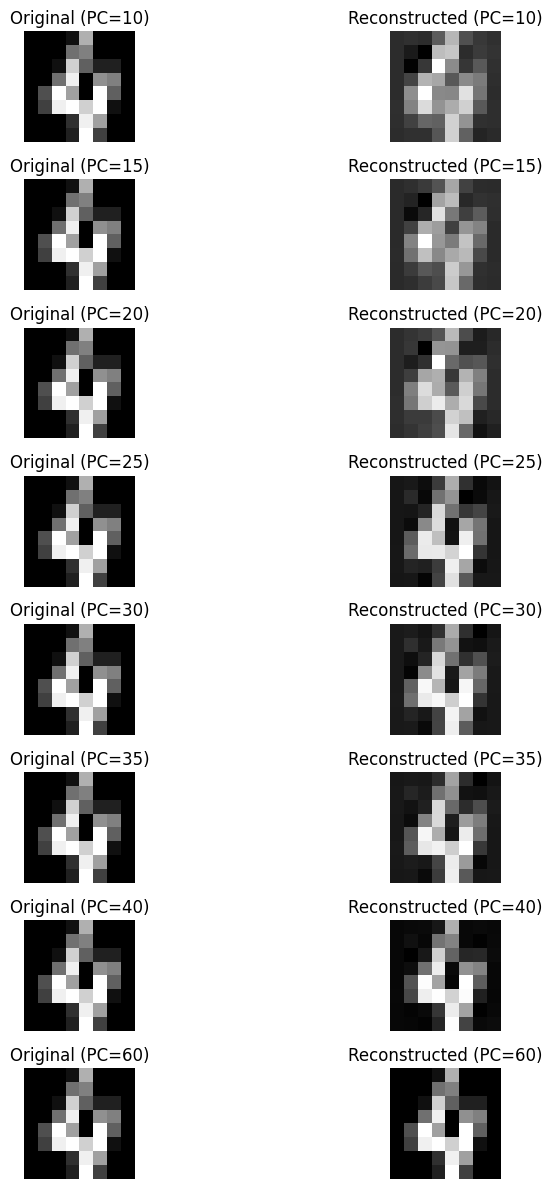

In [206]:
digits = load_digits()
X = digits.data

target_digit = 4
i = list(digits.target).index(target_digit)  

components_list = [10, 15, 20, 25, 30, 35, 40, 60]

fig, axes = plt.subplots(len(components_list), 2, figsize=(10, 12))

for idx, n_components in enumerate(components_list):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)

    axes[idx, 0].imshow(X[i].reshape(8, 8), cmap='gray')
    axes[idx, 0].axis('off')
    axes[idx, 0].set_title(f"Original (PC={n_components})")

    axes[idx, 1].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[idx, 1].axis('off')
    axes[idx, 1].set_title(f"Reconstructed (PC={n_components})")

plt.tight_layout()
plt.show()
